<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/Sensibilidad_centroides.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
from google.colab import userdata
import json

!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = {
    'username': userdata.get('KAGGLE_USER'),
    'key': userdata.get('KAGGLE_KEY')}
with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json


import kagglehub
eph = kagglehub.dataset_download("leonardocaravaggio/ge-images9")
eph2 = kagglehub.dataset_download("leonardocaravaggio/ge-images5")

mkdir: cannot create directory ‘/root/.kaggle’: File exists


100%|██████████| 9.30G/9.30G [03:29<00:00, 47.7MB/s]


Extracting files...


In [60]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import torch.nn.functional as F
import os
import timm
import torch.nn as nn

# Cargar MobileNetV2 hasta la capa 10
model = models.mobilenet_v2(pretrained=True)
model = nn.Sequential(*list(model.features[:10]))
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def _global_pool(feats: torch.Tensor) -> torch.Tensor:
    # Acepta [B,C,H,W] o [B,L,C]
    if feats.dim() == 4:
        # mapa -> avg pool espacial -> [B, C]
        return F.adaptive_avg_pool2d(feats, (1, 1)).squeeze(-1).squeeze(-1)
    elif feats.dim() == 3:
        # tokens -> promedio sobre L -> [B, C]
        return feats.mean(dim=1)
    else:
        raise RuntimeError(f"Forma de features no esperada: {feats.shape}")

def extract_index(image_path):
    image = Image.open(image_path).convert("RGB")
    x = transform(image).unsqueeze(0)  # [1, 3, 224, 224]
    with torch.no_grad():
        feats = model(x)
        # si algún bloque devuelve una tupla/lista, tomamos el primer tensor
        if isinstance(feats, (list, tuple)):
            feats = feats[0]
        pooled = _global_pool(feats).squeeze(0)  # [C]
        inequality_index = np.std(pooled.cpu().numpy())
    return inequality_index

def compute_inequality(image_5km_path, image_10km_path):
    return {
        "Desigualdad_5km": extract_index(image_5km_path),
        "Desigualdad_10km": extract_index(image_10km_path),
    }

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [61]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
from io import BytesIO

def pil_to_bytes(img):
    buf = BytesIO()
    img.save(buf, format='PNG')
    buf.seek(0)
    return buf

def crop_to_square_center(img, size=1773):
    width, height = img.size
    side = min(width, height, size)
    left = (width - side) // 2
    top = (height - side) // 2
    right = left + side
    bottom = top + side
    return img.crop((left, top, right, bottom))

def limpiar_nombre(archivo):
    # Devuelve (ciudad, radio, desplazamiento)
    base = archivo.replace(".png","")
    parts = base.split("_")
    if parts[-1].lower() == "Centro":
        ciudad = " ".join(parts[:-2])
        radio = parts[-2]
        desplazamiento = "Centro"
    else:
        ciudad = " ".join(parts[:-2])
        radio = parts[-2]
        desplazamiento = parts[-1]
    return ciudad, radio, desplazamiento

carpeta = eph  # ahora todo en eph
resultados = []

# Filtrar solo 5K y 10K
imagenes = [f for f in os.listdir(carpeta) if f.endswith(".png") and ("_5K_" in f or "_10K_" in f)]

for archivo in tqdm(imagenes, desc="Procesando imágenes"):
    ciudad, radio, desplazamiento = limpiar_nombre(archivo)
    path = os.path.join(carpeta, archivo)
    img = crop_to_square_center(Image.open(path))
    img_io = pil_to_bytes(img)
    desigualdad = compute_inequality(img_io, img_io)
    valor = desigualdad["Desigualdad_5km"] if radio == "5K" else desigualdad["Desigualdad_10km"]

    resultados.append({
        "Ciudad": ciudad,
        "Radio": radio,
        "Desplazamiento": desplazamiento,
        "Desigualdad": valor
    })

# Convertir a DataFrame
df = pd.DataFrame(resultados)

Procesando imágenes: 100%|██████████| 576/576 [21:43<00:00,  2.26s/it]


In [62]:
# --- 3) Variabilidad separada para 5K y 10K ---
variabilidad = (
    df[df["Desplazamiento"]!="Centro"]
    .groupby(["Ciudad","Radio"])["Desigualdad"]
    .agg(["mean","std"])
    .reset_index()
)

# unir con valor central
centrales_df = df[df["Desplazamiento"]=="Centro"][["Ciudad","Radio","Desigualdad"]].rename(columns={"Desigualdad":"Centro"})
variabilidad = variabilidad.merge(centrales_df, on=["Ciudad","Radio"])
variabilidad["Diff_mean_vs_central"] = variabilidad["mean"] - variabilidad["Centro"]

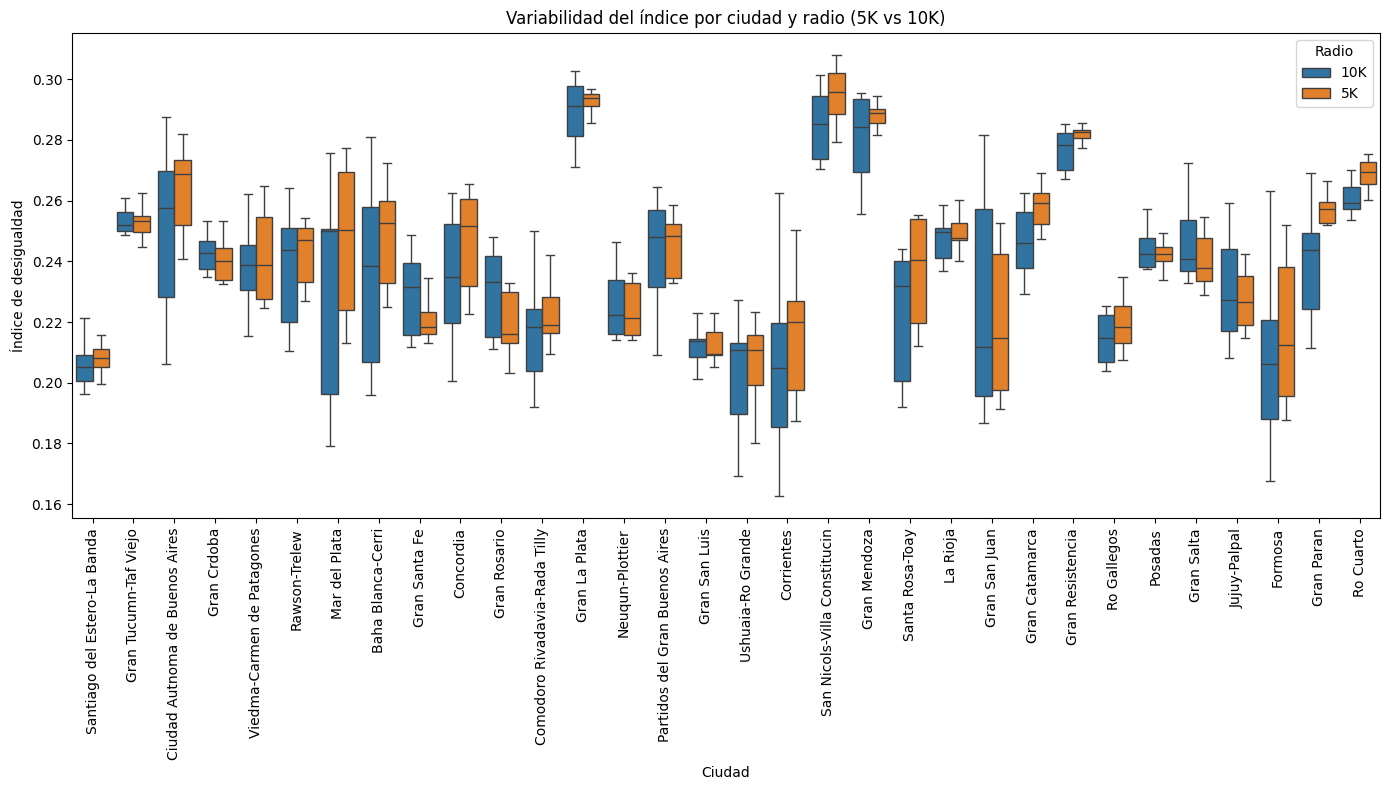

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtramos solo las corridas (no Central)
df_corridas = df[df["Desplazamiento"] != "Central"]

# Ajustamos tamaño general del gráfico
plt.figure(figsize=(14, 8))

# Boxplot: ciudades en eje x, desigualdad en y, separado por Radio
sns.boxplot(
    data=df_corridas,
    x="Ciudad",
    y="Desigualdad",
    hue="Radio",          # colores distintos para 5K y 10K
    showfliers=False      # opcional para ocultar outliers extremos
)

# Rotar etiquetas para que entren
plt.xticks(rotation=90)
plt.title("Variabilidad del índice por ciudad y radio (5K vs 10K)")
plt.xlabel("Ciudad")
plt.ylabel("Índice de desigualdad")

plt.tight_layout()
plt.show()


In [64]:
# Diccionario de corrección manual
correcciones = {
    "Gran Crdoba": "Gran Córdoba",
    "Neuqun-Plottier": "Neuquén-Plottier",
    "Ushuaia-Ro Grande": "Ushuaia-Río Grande",
    "Gran Paran": "Gran Paraná",
    "Ro Cuarto": "Río Cuarto",
    "Baha Blanca-Cerri": "Bahía Blanca-Cerri",
    "Ciudad Autnoma de Buenos Aires": "Ciudad Autónoma de Buenos Aires",
    "San Nicols-Villa Constitucin": "San Nicolás-Villa Constitución",
    "Jujuy-Palpal": "Jujuy-Palpalá",
    "Gran Tucumn-Taf Viejo": "Gran Tucumán-Tafí Viejo",
}

# Reemplazar en df
df["Ciudad"] = df["Ciudad"].replace(correcciones)

ciudades = pd.read_csv("Gini_EPH.csv")
ciudades["Ciudad"]=ciudades["Nombre_Aglomerado"]
df_merged = df.merge(ciudades[["Ciudad","Gini_Hogares"]], on="Ciudad", how="left")

In [65]:
from scipy.stats import pearsonr

resultados_correlacion = []

for radio in ["5K","10K"]:
    for desplazamiento in df_merged["Desplazamiento"].unique():
        df_sub = df_merged[(df_merged["Radio"]==radio) &
                           (df_merged["Desplazamiento"]==desplazamiento)]
        # eliminar nulos
        mask = df_sub["Desigualdad"].notna() & df_sub["Gini_Hogares"].notna()
        if mask.sum()>2:  # al menos 3 puntos para correlación
            r, p = pearsonr(df_sub.loc[mask,"Desigualdad"], df_sub.loc[mask,"Gini_Hogares"])
            resultados_correlacion.append({
                "Radio": radio,
                "Desplazamiento": desplazamiento,
                "r": r,
                "p": p,
                "N": mask.sum()
            })

df_corr = pd.DataFrame(resultados_correlacion)
print(df_corr)


   Radio Desplazamiento         r         p   N
0     5K           Este  0.399265  0.026073  31
1     5K        SurEste  0.320198  0.079072  31
2     5K            Sur  0.388131  0.030958  31
3     5K      NorteEste  0.522396  0.002573  31
4     5K       SurOeste  0.362120  0.045299  31
5     5K          Norte  0.569852  0.000819  31
6     5K         Centro  0.474733  0.006965  31
7     5K          Oeste  0.363118  0.044665  31
8     5K     NorteOeste  0.427091  0.016562  31
9    10K           Este  0.294410  0.107899  31
10   10K        SurEste  0.190523  0.304591  31
11   10K            Sur  0.339030  0.062075  31
12   10K      NorteEste  0.407693  0.022811  31
13   10K       SurOeste  0.413798  0.020664  31
14   10K          Norte  0.586883  0.000520  31
15   10K         Centro  0.480538  0.006215  31
16   10K          Oeste  0.403508  0.024386  31
17   10K     NorteOeste  0.417725  0.019373  31


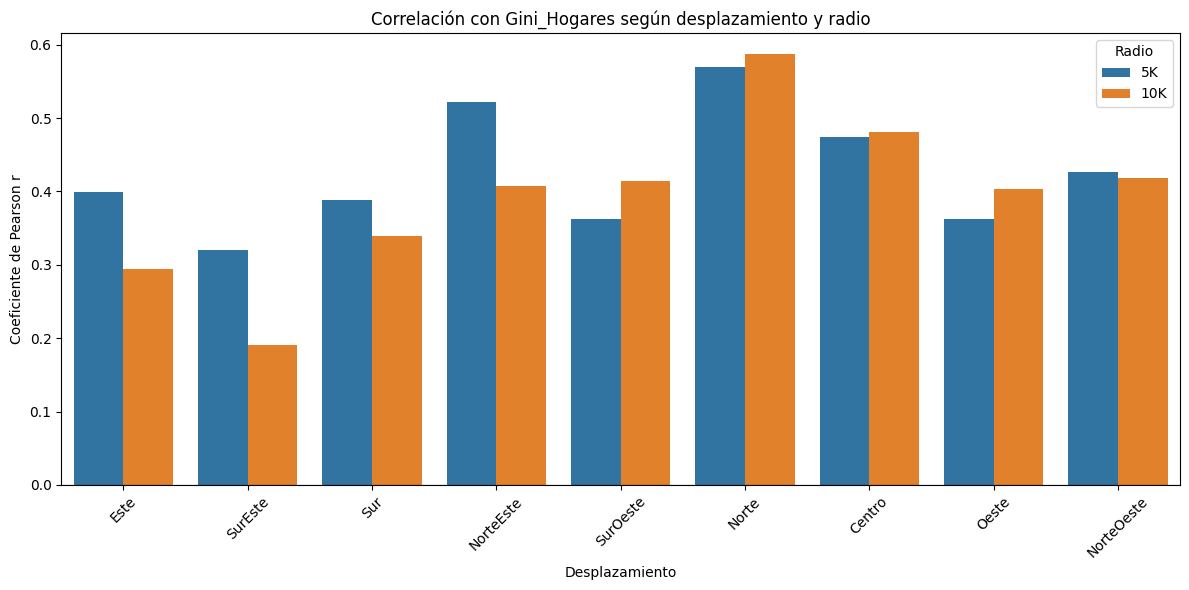

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=df_corr, x="Desplazamiento", y="r", hue="Radio")
plt.axhline(0.0,color="black",linewidth=0.8)
plt.title("Correlación con Gini_Hogares según desplazamiento y radio")
plt.ylabel("Coeficiente de Pearson r")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [67]:
import numpy as np
from scipy.stats import pearsonr

resultados_random = []

n_iter = 1000  # cantidad de simulaciones

for radio in ["5K", "10K"]:
    # subset solo de ese radio
    df_radio = df_merged[df_merged["Radio"]==radio]

    ciudades_unicas = df_radio["Ciudad"].unique()

    for i in range(n_iter):
        # Para cada ciudad elegimos un desplazamiento al azar
        muestras = []
        for ciudad in ciudades_unicas:
            df_ciudad = df_radio[df_radio["Ciudad"]==ciudad]
            if not df_ciudad.empty:
                # elegir fila random
                fila_random = df_ciudad.sample(1)
                muestras.append(fila_random)
        # concatenar en un df
        df_sample = pd.concat(muestras)

        mask = df_sample["Desigualdad"].notna() & df_sample["Gini_Hogares"].notna()

        if mask.sum()>2:
            r, p = pearsonr(df_sample.loc[mask,"Desigualdad"],
                            df_sample.loc[mask,"Gini_Hogares"])
            resultados_random.append({
                "Radio": radio,
                "Iteracion": i,
                "r": r,
                "p": p,
                "N": mask.sum()
            })

df_random = pd.DataFrame(resultados_random)


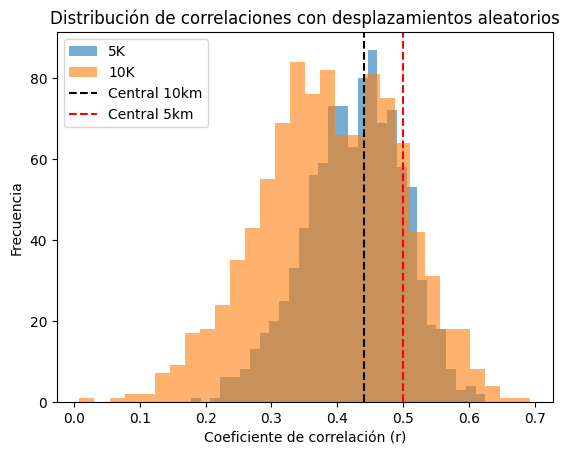

In [75]:
df_random.groupby("Radio")["r"].agg(["mean","std"])
import matplotlib.pyplot as plt

# Histograma por Radio
for radio in ["5K","10K"]:
    plt.hist(df_random[df_random["Radio"]==radio]["r"], bins=30, alpha=0.6, label=radio)

# Líneas verticales fijas para las centrales
plt.axvline(x=0.44, color='k', linestyle='--', label="Central 10km")
plt.axvline(x=0.50, color='r', linestyle='--', label="Central 5km")

plt.legend()
plt.xlabel("Coeficiente de correlación (r)")
plt.ylabel("Frecuencia")
plt.title("Distribución de correlaciones con desplazamientos aleatorios")
plt.show()